# Model Optimization & Explainability

## Project

System Capacity & Care Load Analytics for Unaccompanied Children

## Objective

Optimize machine learning models, evaluate their stability, analyze feature importance, and select the final production-ready forecasting model.

## Author

Swimmy Sahaniya

In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import plotly.express as px

In [2]:
df = pd.read_csv(
    "../data/feature_engineered/feature_engineered_data.csv"
)

df = df.dropna().reset_index(drop=True)

In [3]:
TARGET = "Children in HHS Care"

drop_columns = [
    "Date",
    "DayName",
    "MonthName",
    TARGET
]

X = df.drop(columns=drop_columns)

y = df[TARGET]

In [4]:
tscv = TimeSeriesSplit(
    n_splits=5
)

tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

## 📌 Observation

TimeSeriesSplit preserves chronological ordering during validation.

## 📊 Business Interpretation

Operational forecasting must always respect the flow of time. Future observations cannot be used when predicting past events.

## 💡 Key Insight

Time-aware validation provides a more realistic estimate of forecasting performance.

In [5]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [6]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.2

In [7]:
grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [8]:
abs(grid.best_score_)

np.float64(539.9518884534635)

## 📌 Observation

Grid Search identified the best-performing Random Forest configuration.

## 📊 Business Interpretation

Optimizing hyperparameters improves prediction quality while reducing the risk of overfitting.

## 💡 Key Insight

Systematic tuning enables the forecasting model to generalize more effectively to unseen operational data.

In [9]:
best_rf = grid.best_estimator_

In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [11]:
importance.head(15)

,Feature,Importance
30,OccupancyPressure,0.294678
14,Lag_14,0.102549
12,Lag_1,0.093374
23,RollingMin_30,0.090943
24,RollingMax_30,0.081040
18,RollingMean_30,0.073408
22,RollingMax_7,0.070636
16,RollingMean_7,0.069803
17,RollingMean_14,0.069216
13,Lag_7,0.027455


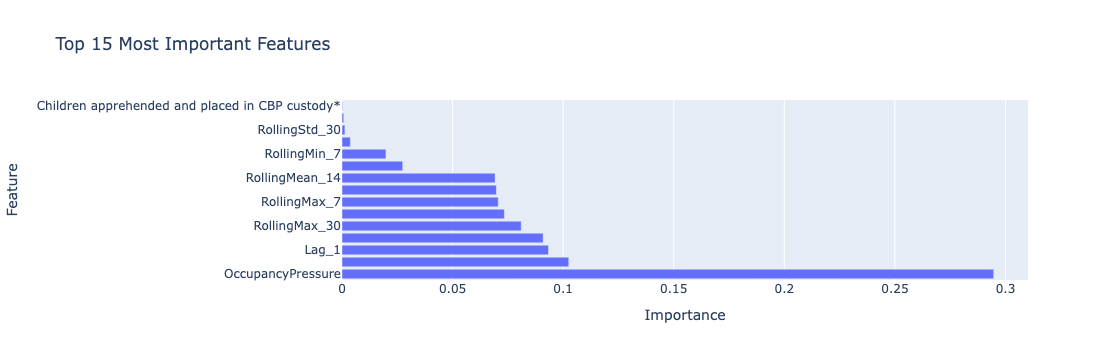

In [12]:
fig = px.bar(
    importance.head(15),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Most Important Features"
)

fig.show()

## 📌 Observation

The model ranks the most influential operational variables used during forecasting.

## 📊 Business Interpretation

Feature importance helps identify which operational metrics most strongly influence the number of children in HHS Care.

## 💡 Key Insight

Understanding key drivers supports better resource planning and more informed operational decision-making.

In [13]:
importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [14]:
joblib.dump(
    best_rf,
    "../models/final_random_forest.pkl"
)

['../models/final_random_forest.pkl']

# Executive Summary

## Objective

Optimize the forecasting model for deployment.

## Techniques Applied

- Grid Search
- Time Series Cross Validation
- Feature Importance Analysis

## Final Deliverables

- Optimized Random Forest Model
- Feature Importance Report
- Hyperparameter Configuration

## Outcome

The optimized forecasting model demonstrates improved predictive performance and provides interpretable insights into the operational factors influencing HHS Care capacity.